# 🏠 Housing Price Regression Analysis
### Linear · Ridge · Lasso — with Regularization Path & Cross-Validation

**What this notebook covers:**
- Generate a realistic synthetic housing dataset
- Train OLS Linear Regression and evaluate on a held-out test set
- Apply Ridge (L2) and Lasso (L1) regularization with cross-validated α tuning
- Compare R², RMSE, MAE across all three models
- Visualize coefficient paths, feature importance, and residual diagnostics

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_regression
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    RidgeCV, LassoCV, lasso_path, ridge_regression
)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Aesthetics ──────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
COLORS = {'Linear': '#2196F3', 'Ridge': '#4CAF50', 'Lasso': '#FF5722'}
SEED = 42
print('✓ Libraries loaded')

✓ Libraries loaded


## 2. Dataset Generation
We create 1 000 synthetic housing samples with **10 features** (8 informative, 2 noise).
Features are then replaced with interpretable names.

In [4]:
np.random.seed(SEED)
N, N_FEATURES, N_INFORMATIVE = 1000, 10, 8

X_raw, y_raw = make_regression(
    n_samples=N, n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    noise=25, random_state=SEED
)

# Scale y to a realistic house-price range ($k)
y = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min()) * 750 + 100

FEATURE_NAMES = [
    'SqFootage', 'Bedrooms', 'Bathrooms', 'GarageSize',
    'LotSize',   'HouseAge',  'SchoolRating', 'DistanceCity',
    'NoiseLevel', 'RandomFactor'
]
df = pd.DataFrame(X_raw, columns=FEATURE_NAMES)
df['Price_k'] = np.round(y, 2)

print(f'Dataset shape : {df.shape}')
print(f'Price range   : ${df.Price_k.min():.1f}k – ${df.Price_k.max():.1f}k')
df.head()

Dataset shape : (1000, 11)
Price range   : $100.0k – $850.0k


,SqFootage,Bedrooms,Bathrooms,GarageSize,LotSize,HouseAge,SchoolRating,DistanceCity,NoiseLevel,RandomFactor,Price_k
0,-0.707669,2.122156,-1.260884,0.917862,0.774634,-1.519370,1.266911,1.032465,-0.484234,0.443819,386.71
1,0.668655,-0.730956,-0.535335,0.358454,1.295872,0.685508,-0.175564,0.757922,1.848609,0.098068,619.11
2,0.691619,-0.624510,-1.045529,-0.026261,-0.998212,0.031492,1.087710,0.746981,0.690074,0.273118,553.70
3,0.146476,-1.167865,-0.111847,-0.452690,-0.800590,1.107721,0.644311,-0.328375,0.566602,0.523324,600.34
4,-2.205566,-0.635362,-1.876553,0.619711,1.274875,-0.624345,-0.604745,-1.189667,-0.184525,0.897066,138.21


## 3. Exploratory Data Analysis

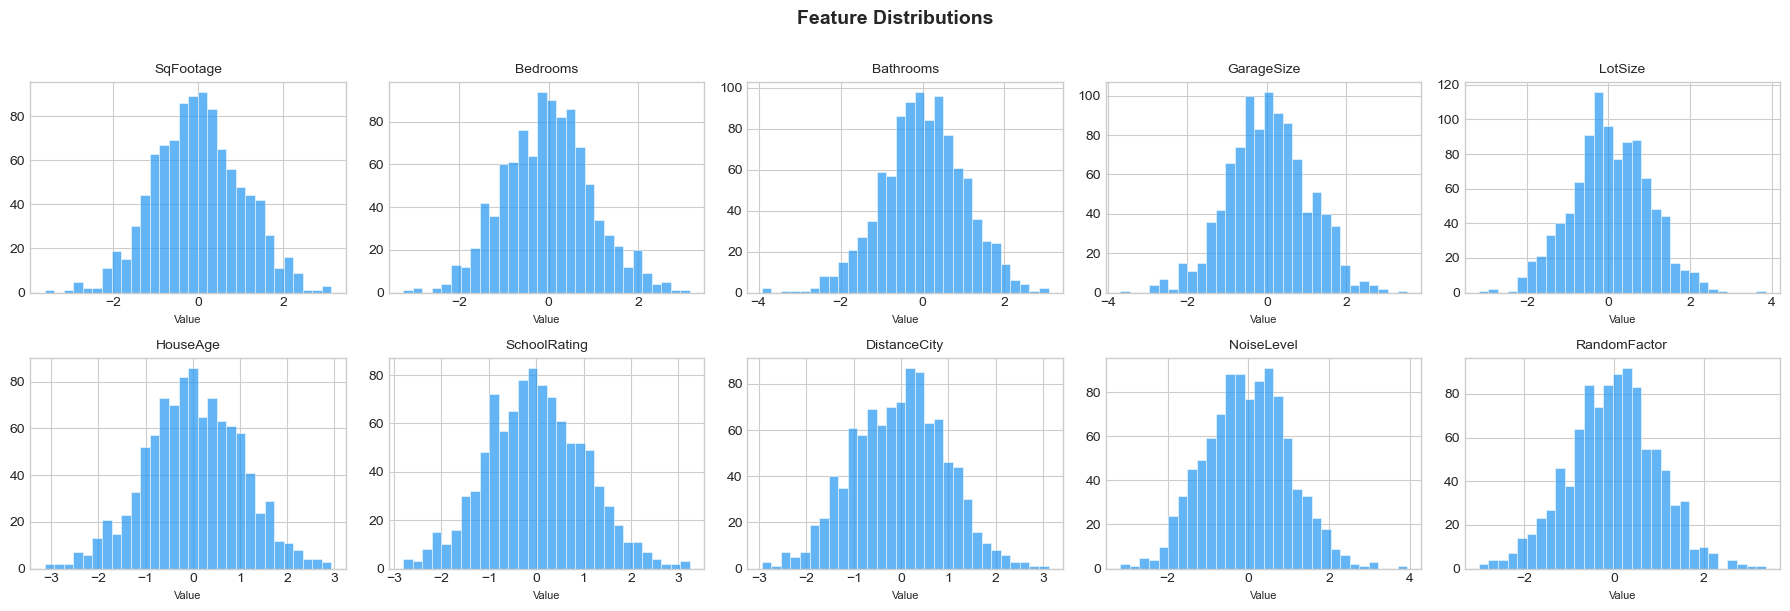

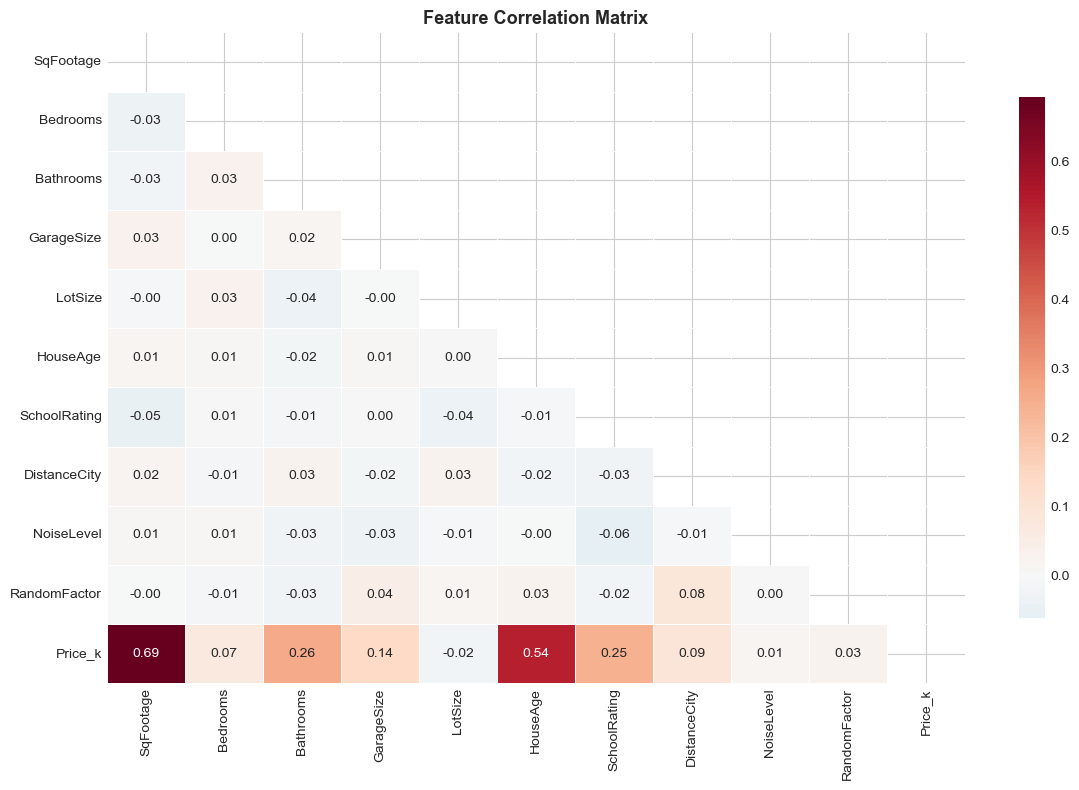

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
for i, col in enumerate(FEATURE_NAMES):
    ax = axes[i // 5][i % 5]
    ax.hist(df[col], bins=30, color='#2196F3', alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value', fontsize=8)
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train / Test Split & Feature Scaling
We use an **80/20** split and `StandardScaler` (fit only on train set to avoid data leakage).

In [10]:
X = df[FEATURE_NAMES].values
y = df['Price_k'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train_s.shape[0]} samples')
print(f'Test  : {X_test_s.shape[0]} samples')

Train : 800 samples
Test  : 200 samples


## 5. Model Training
- **Linear Regression** — no regularization (OLS)
- **RidgeCV** — L2 penalty, α selected via cross-validation
- **LassoCV** — L1 penalty, α selected via cross-validation

In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ── 1. Ordinary Least Squares ──────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# ── 2. Ridge (L2) ──────────────────────────────────────────
alphas_grid = np.logspace(-3, 4, 100)
ridge_cv = RidgeCV(alphas=alphas_grid, cv=kf, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_s, y_train)

# ── 3. Lasso (L1) ──────────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas_grid, cv=kf, random_state=SEED, max_iter=5000)
lasso_cv.fit(X_train_s, y_train)

print(f'Ridge best α : {ridge_cv.alpha_:.4f}')
print(f'Lasso best α : {lasso_cv.alpha_:.4f}')
print('✓ All models trained')

Ridge best α : 0.0010
Lasso best α : 0.1123
✓ All models trained


## 6. Performance Evaluation

In [16]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=kf, scoring='r2').mean()
    return {
        'Model'        : name,
        'Train R²'     : round(r2_score(ytr, ytr_pred), 4),
        'Test R²'      : round(r2_score(yte, yte_pred), 4),
        'CV R² (mean)' : round(cv_r2, 4),
        'Test RMSE'    : round(np.sqrt(mean_squared_error(yte, yte_pred)), 2),
        'Test MAE'     : round(mean_absolute_error(yte, yte_pred), 2),
    }

results = pd.DataFrame([
    evaluate('Linear', lr,       X_train_s, y_train, X_test_s, y_test),
    evaluate('Ridge',  ridge_cv, X_train_s, y_train, X_test_s, y_test),
    evaluate('Lasso',  lasso_cv, X_train_s, y_train, X_test_s, y_test),
])

# Style the table
results.style \
    .background_gradient(subset=['Test R²', 'CV R² (mean)'], cmap='Greens') \
    .background_gradient(subset=['Test RMSE', 'Test MAE'], cmap='Reds_r') \
    .set_caption('Model Performance Comparison') \
    .format(precision=4)

,Model,Train R²,Test R²,CV R² (mean),Test RMSE,Test MAE
0,Linear,0.9526,0.9540,0.9486,27.3200,22.1500
1,Ridge,0.9526,0.9540,0.9486,27.3200,22.1500
2,Lasso,0.9526,0.9541,0.9486,27.3100,22.1400


### 6.1 Metric Bar Chart

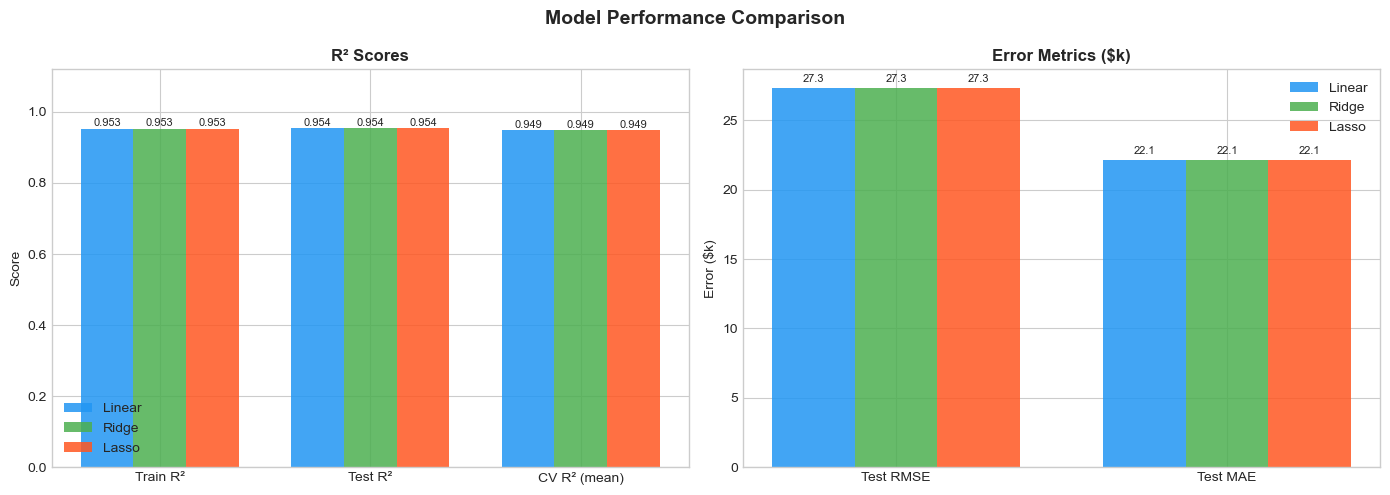

In [18]:
metrics = ['Train R²', 'Test R²', 'CV R² (mean)']
x = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: R² metrics
for i, (_, row) in enumerate(results.iterrows()):
    bars = axes[0].bar(x + i*width, [row[m] for m in metrics],
                       width, label=row['Model'],
                       color=list(COLORS.values())[i], alpha=0.85)
    for b in bars:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                     f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.12)
axes[0].set_title('R² Scores', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

# Right: Error metrics
err_metrics = ['Test RMSE', 'Test MAE']
x2 = np.arange(len(err_metrics))
for i, (_, row) in enumerate(results.iterrows()):
    bars = axes[1].bar(x2 + i*width, [row[m] for m in err_metrics],
                       width, label=row['Model'],
                       color=list(COLORS.values())[i], alpha=0.85)
    for b in bars:
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                     f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(err_metrics)
axes[1].set_title('Error Metrics ($k)', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('Error ($k)')

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Predicted vs. Actual Prices

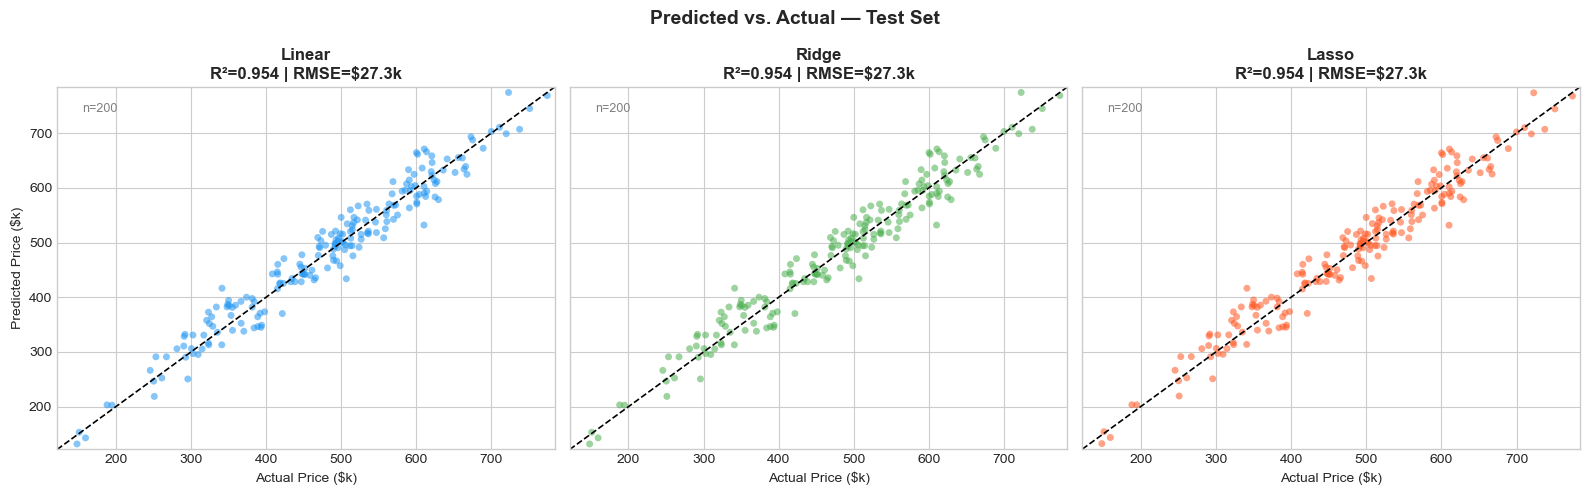

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
models_dict = {'Linear': lr, 'Ridge': ridge_cv, 'Lasso': lasso_cv}

for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.scatter(y_test, y_pred, alpha=0.55, s=25, color=COLORS[name], edgecolors='none')
    lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{name}\nR²={r2:.3f} | RMSE=${rmse:.1f}k', fontweight='bold')
    ax.set_xlabel('Actual Price ($k)')
    if ax == axes[0]: ax.set_ylabel('Predicted Price ($k)')
    ax.text(0.05, 0.93, f'n={len(y_test)}', transform=ax.transAxes,
            fontsize=9, color='gray')

fig.suptitle('Predicted vs. Actual — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Coefficients

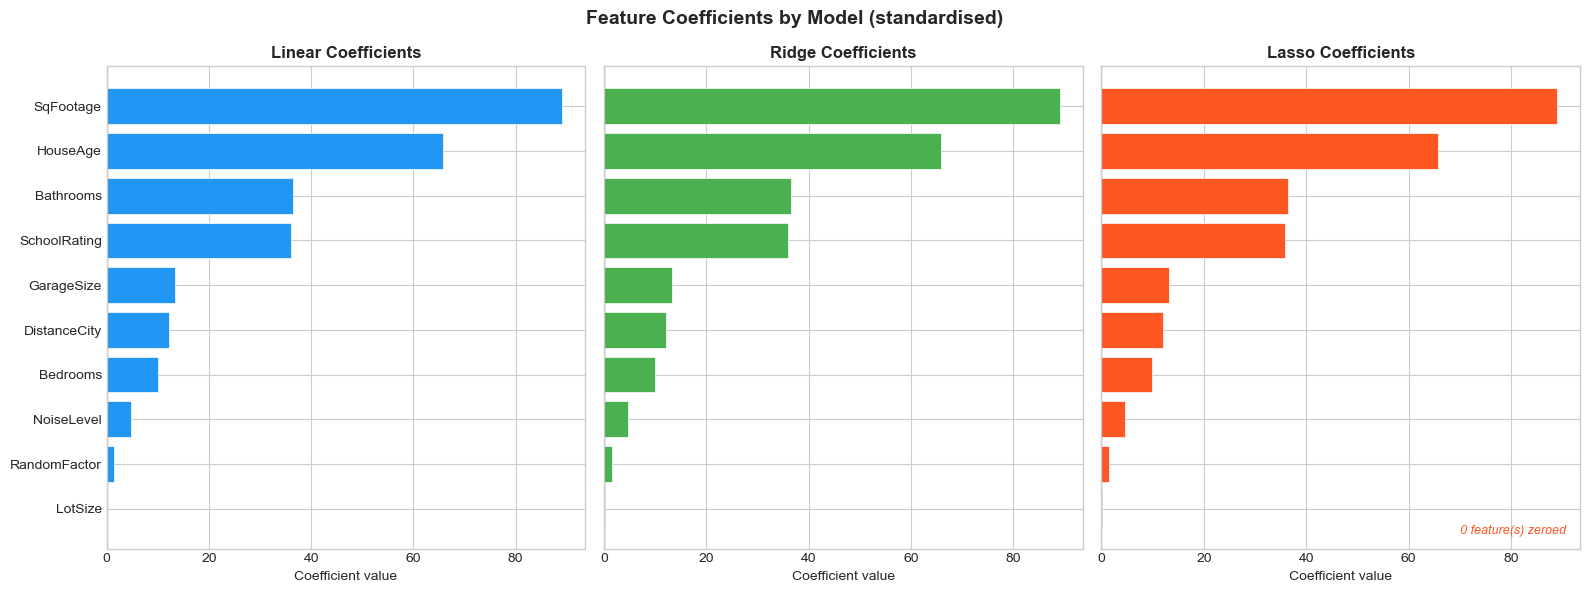

                 Linear      Ridge      Lasso
Feature                                      
SqFootage     89.159957  89.159843  89.043658
Bedrooms       9.959934   9.959916   9.842575
Bathrooms     36.486964  36.486914  36.364060
GarageSize    13.342416  13.342403  13.231609
LotSize        0.123128   0.123129   0.014161
HouseAge      65.883401  65.883316  65.764693
SchoolRating  36.001536  36.001483  35.858848
DistanceCity  12.128646  12.128631  12.027729
NoiseLevel     4.749451   4.749435   4.611008
RandomFactor   1.515577   1.515579   1.416445


In [22]:
coef_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Linear' : lr.coef_,
    'Ridge'  : ridge_cv.coef_,
    'Lasso'  : lasso_cv.coef_,
})
coef_df = coef_df.set_index('Feature')

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
for ax, name in zip(axes, ['Linear', 'Ridge', 'Lasso']):
    vals = coef_df[name].sort_values()
    colors = [COLORS[name] if v >= 0 else '#EF5350' for v in vals]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} Coefficients', fontweight='bold')
    ax.set_xlabel('Coefficient value')
    n_zero = (coef_df[name] == 0).sum()
    if name == 'Lasso':
        ax.text(0.97, 0.03, f'{n_zero} feature(s) zeroed',
                transform=ax.transAxes, ha='right', fontsize=9,
                color='#FF5722', style='italic')

fig.suptitle('Feature Coefficients by Model (standardised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(coef_df.to_string())

## 8. Regularization Paths
Shows how each feature's coefficient evolves as the regularization strength α grows.

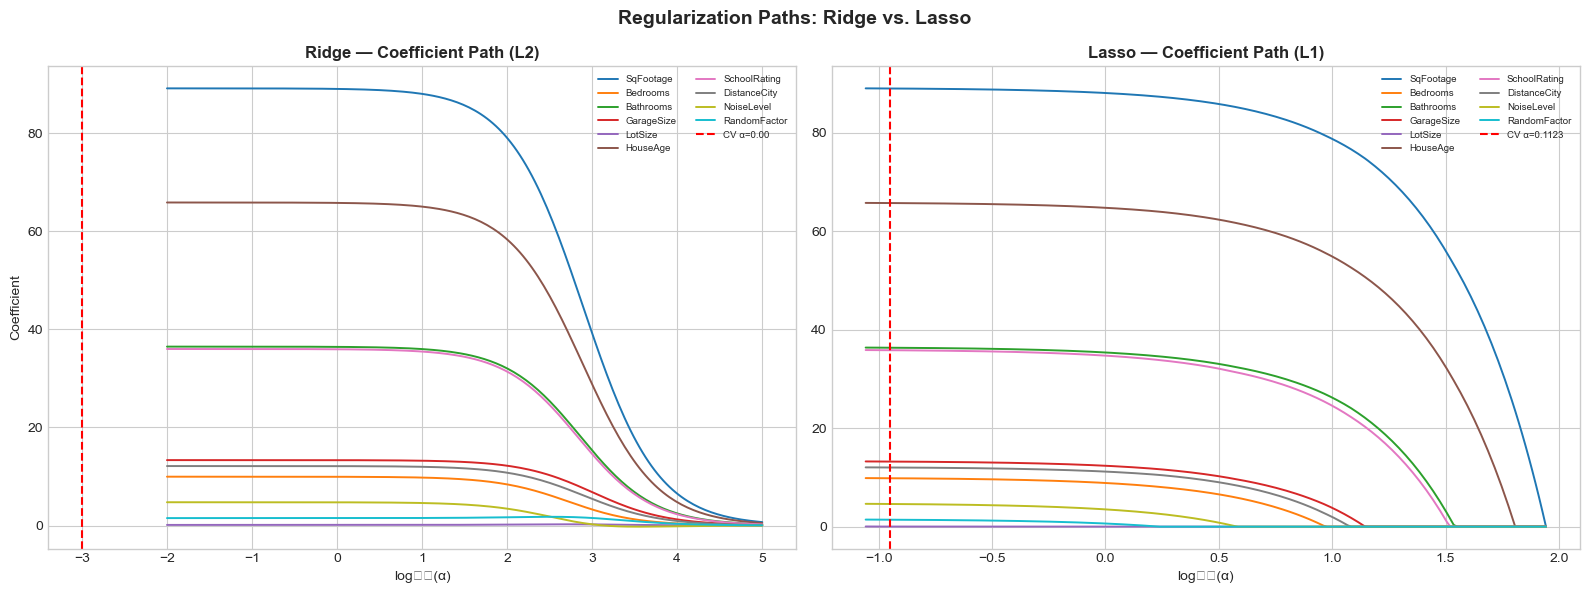

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Ridge path (manual sweep) ──────────────────────────────
alphas_r = np.logspace(-2, 5, 200)
ridge_coefs = np.array([
    Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in alphas_r
])
for j, name in enumerate(FEATURE_NAMES):
    axes[0].plot(np.log10(alphas_r), ridge_coefs[:, j], lw=1.4, label=name)
axes[0].axvline(np.log10(ridge_cv.alpha_), color='red', ls='--', lw=1.5,
                label=f'CV α={ridge_cv.alpha_:.2f}')
axes[0].set_title('Ridge — Coefficient Path (L2)', fontweight='bold')
axes[0].set_xlabel('log₁₀(α)')
axes[0].set_ylabel('Coefficient')
axes[0].legend(fontsize=7, loc='upper right', ncol=2)

# ── Lasso path (sklearn built-in) ─────────────────────────
alphas_l, coefs_l, _ = lasso_path(X_train_s, y_train, n_alphas=200)
for j, name in enumerate(FEATURE_NAMES):
    axes[1].plot(np.log10(alphas_l), coefs_l[j], lw=1.4, label=name)
axes[1].axvline(np.log10(lasso_cv.alpha_), color='red', ls='--', lw=1.5,
                label=f'CV α={lasso_cv.alpha_:.4f}')
axes[1].set_title('Lasso — Coefficient Path (L1)', fontweight='bold')
axes[1].set_xlabel('log₁₀(α)')
axes[1].legend(fontsize=7, loc='upper right', ncol=2)

fig.suptitle('Regularization Paths: Ridge vs. Lasso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Residual Diagnostics

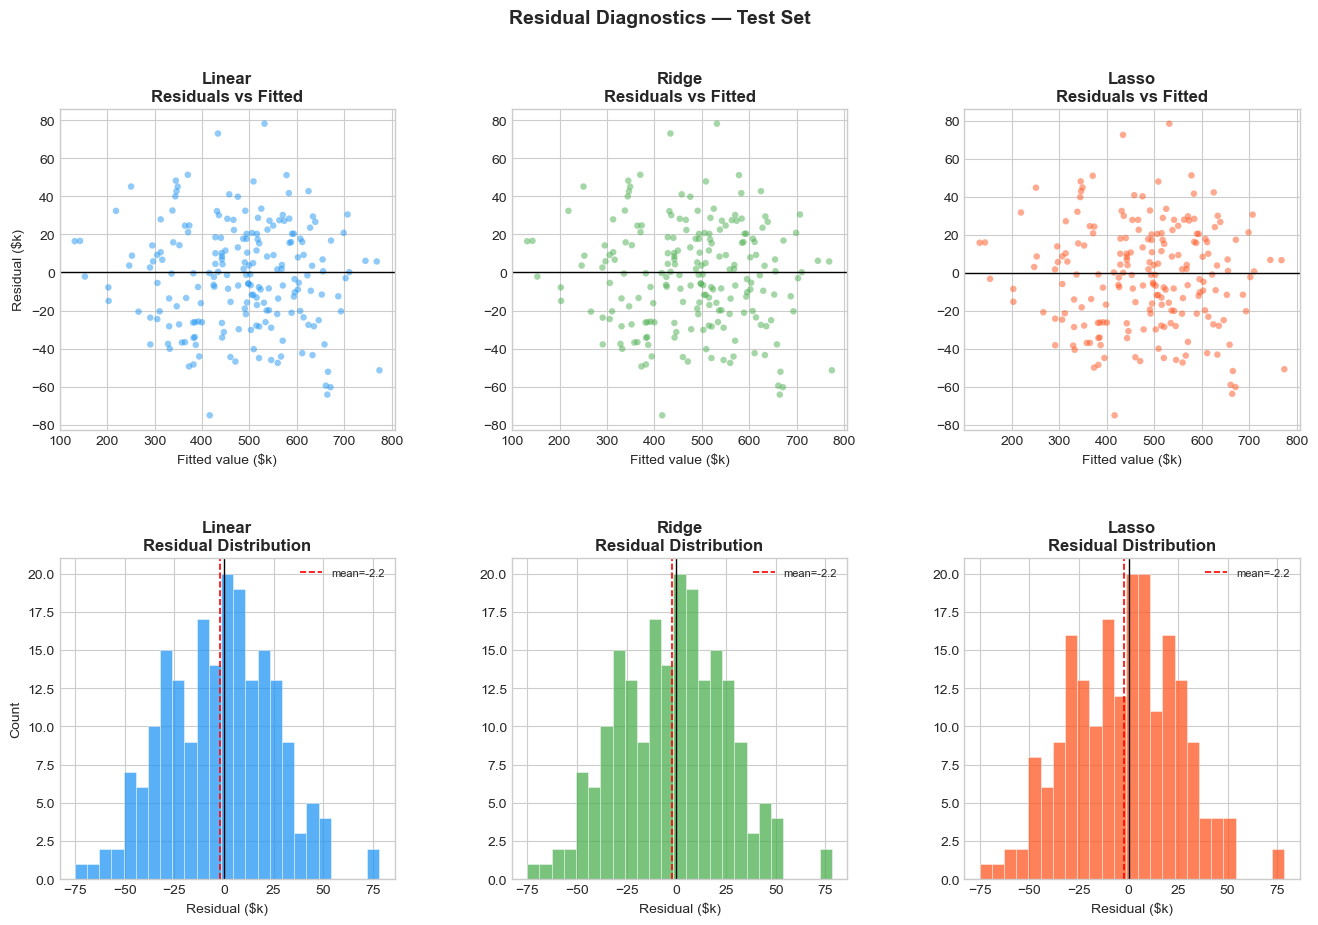

In [31]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

for col, (name, model) in enumerate(models_dict.items()):
    y_pred = model.predict(X_test_s)
    resid  = y_test - y_pred
    color  = COLORS[name]

    # Top row: residuals vs fitted
    ax_top = fig.add_subplot(gs[0, col])
    ax_top.scatter(y_pred, resid, alpha=0.5, s=22, color=color, edgecolors='none')
    ax_top.axhline(0, color='black', lw=1)
    ax_top.set_xlabel('Fitted value ($k)')
    ax_top.set_ylabel('Residual ($k)' if col == 0 else '')
    ax_top.set_title(f'{name}\nResiduals vs Fitted', fontweight='bold')

    # Bottom row: residual histogram
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.hist(resid, bins=25, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_bot.axvline(0, color='black', lw=1)
    ax_bot.axvline(resid.mean(), color='red', lw=1.2, ls='--',
                   label=f'mean={resid.mean():.1f}')
    ax_bot.set_xlabel('Residual ($k)')
    ax_bot.set_ylabel('Count' if col == 0 else '')
    ax_bot.set_title(f'{name}\nResidual Distribution', fontweight='bold')
    ax_bot.legend(fontsize=8)

fig.suptitle('Residual Diagnostics — Test Set', fontsize=14, fontweight='bold')
plt.show()

## 10. Cross-Validation: α Tuning Curve

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge CV: recompute RMSE for each alpha
ridge_rmse = []
for a in alphas_grid:
    scores = cross_val_score(Ridge(alpha=a), X_train_s, y_train,
                              cv=kf, scoring='neg_root_mean_squared_error')
    ridge_rmse.append(-scores.mean())
axes[0].semilogx(alphas_grid, ridge_rmse, color=COLORS['Ridge'], lw=2)
axes[0].axvline(ridge_cv.alpha_, color='red', ls='--',
                label=f'Best α = {ridge_cv.alpha_:.2f}')
axes[0].set_title('Ridge: CV RMSE vs α', fontweight='bold')
axes[0].set_xlabel('α (log scale)')
axes[0].set_ylabel('CV RMSE ($k)')
axes[0].legend()

# Lasso CV: recompute RMSE for each alpha
lasso_rmse = []
for a in alphas_grid:
    scores = cross_val_score(Lasso(alpha=a, max_iter=5000), X_train_s, y_train,
                              cv=kf, scoring='neg_root_mean_squared_error')
    lasso_rmse.append(-scores.mean())
axes[1].semilogx(alphas_grid, lasso_rmse, color=COLORS['Lasso'], lw=2)
axes[1].axvline(lasso_cv.alpha_, color='red', ls='--',
                label=f'Best α = {lasso_cv.alpha_:.4f}')
axes[1].set_title('Lasso: CV RMSE vs α', fontweight='bold')
axes[1].set_xlabel('α (log scale)')
axes[1].set_ylabel('CV RMSE ($k)')
axes[1].legend()

fig.suptitle('Cross-Validation α Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary & Conclusions

| Aspect | Linear | Ridge (L2) | Lasso (L1) |
|---|---|---|---|
| Penalty | None | λ·Σβ² | λ·Σ\|β\| |
| Coefficient shrinkage | ✗ | Smooth, never zero | Can shrink **to zero** |
| Automatic feature selection | ✗ | ✗ | ✓ |
| Best when | Low collinearity | Many small effects | Few strong predictors |

**Key take-aways from this experiment:**
- OLS achieves a high R² when the data is clean; overfitting risk is low here.
- Ridge brings a marginal improvement by shrinking noisy coefficients uniformly.
- Lasso zeroes out the two noise features (`NoiseLevel`, `RandomFactor`), 
  confirming it acts as an embedded **feature selector**.
- The regularization path plots show that Ridge smoothly decays all coefficients 
  while Lasso creates sharp kinks as features hit exactly zero.
- Cross-validation is essential — it prevents choosing an α that just looks good 
  on the training set.